In [78]:
import warnings
warnings.simplefilter('ignore')
import sys
sys.path.append('../pybeh')
import cmlreaders as cml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import pandas_to_pybeh as pb
import scipy as scp
import re
import math
import pickle
pd.options.display.max_rows = 100
pd.options.display.max_columns = 50

%matplotlib inline
import importlib
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
from collections import defaultdict

In [41]:
subjects = ['LTP564', 'LTP565', 'LTP566', 'LTP567', 'LTP568', 'LTP569', 'LTP571', 'LTP572', 'LTP573',
            'LTP574', 'LTP575', 'LTP576', 'LTP577', 'LTP578', 'LTP579', 'LTP580', 'LTP581', 'LTP583',
            'LTP584', 'LTP585', 'LTP586', 'LTP587', 'LTP588', 'LTP589', 'LTP590', 'LTP591', 'LTP592', 
            'LTP593', 'LTP594', 'LTP595', 'LTP596', 'LTP597', 'LTP598', 'LTP599', 'LTP600', 'LTP601', 
            'LTP602', 'LTP603', 'LTP604', 'LTP605']

In [42]:
experiment = 'CourierReinstate1'
data = cml.get_data_index(kind = 'ltp')
data = data[(data['experiment']==experiment)].sort_values('session').reset_index()

full_evs = None
for i, row in data.iterrows():
    # intialize data reader, load words events and buffered eeg epochs
    r = cml.CMLReader(subject=row['subject'], experiment=row['experiment'], session=row['session'])
    evs = r.load('task_events')
    full_evs = evs if full_evs is None else pd.concat([full_evs, evs], ignore_index=True)
full_evs = full_evs.query('subject in @subjects')

In [43]:
full_evs = full_evs[(full_evs['item'] != "AMPLIFIER") & (full_evs['item'] != "APPLE") & (full_evs['item'] != "AXE") & 
                    (full_evs['item'] != "BASKETBALL_HOOP") & (full_evs['item'] != "DOOR") & (full_evs['item'] != "IRONING_BOARD") & 
                    (full_evs['item'] != "SHOVEL") & (full_evs['item'] != "STOVE")]
full_evs

,eegoffset,classifier,correctPointingDirection,eegfile,efr_mark,eogArtifact,experiment,finalrecalled,intruded,intrusion,item,itemno,montage,msoffset,mstime,phase,presX,presZ,protocol,recalled,rectime,serialpos,session,store,storeX,storeZ,subject,submittedPointingDirection,trial,type
0,188099,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1752089748679,1,-999.000000,-999.000000,ltp,-999,-999,-999,0,-999,-999.00000,-999.00000,LTP592,-999,0,store mappings
1,202442,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-1,0,-1,1752089755684,1,-999.000000,-999.000000,ltp,-999,-999,-999,0,-999,-999.00000,-999.00000,LTP592,-999,0,VIDEO_START
2,605229,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-1,0,-1,1752089952398,1,-999.000000,-999.000000,ltp,-999,-999,-999,0,-999,-999.00000,-999.00000,LTP592,-999,0,VIDEO_STOP
3,820132,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1752090057353,1,-999.000000,-999.000000,ltp,-999,-999,-999,0,-999,-999.00000,-999.00000,LTP592,-999,0,TL_START
4,1548717,X,-999,/protocols/ltp/subjects/LTP592/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1752090413181,1,46.406250,29.484375,ltp,-999,-999,-999,0,-999,-999.00000,-999.00000,LTP592,-999,0,TL_END
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216727,7652143,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,0,TABLE,35,0,20,1748468097506,1,-26.515625,-46.218750,ltp,-999,17054,4,6,cafe,59.28125,-9.15625,LTP571,-999,9,REC_WORD
216728,7703205,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,0,COFFEE_MACHINE,81,0,20,1748468122440,1,-26.515625,-46.218750,ltp,-999,41988,2,6,bakery,-60.00000,-11.50000,LTP571,-999,9,REC_WORD
216729,7704628,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,0,REFRIGERATOR,53,0,20,1748468123135,1,-26.515625,-46.218750,ltp,-999,42683,1,6,music_store,-31.81250,55.71875,LTP571,-999,9,REC_WORD
216730,7801530,X,-999,/protocols/ltp/subjects/LTP571/experiments/Cou...,-999,-1,CourierReinstate1,-999,-999,-999,-999,-999,0,-1,1748468170452,1,-26.515625,-46.218750,ltp,-999,-999,-999,6,-999,-999.00000,-999.00000,LTP571,-999,9,REC_STOP


In [44]:
with open("courier_wordpool_fixed.txt") as f:
    pool_raw = [w.strip() for w in f if w.strip()]
if pool_raw and pool_raw[0].lower() == "word":
    pool_raw = pool_raw[1:]

pool = [w.upper() for w in pool_raw]
pool_map = {w: i+1 for i, w in enumerate(pool)}

def norm(s):
    return (str(s).strip().upper().replace(" ", "_"))

full_evs["item_key"] = full_evs["item"].map(norm)
full_evs["itemno"]   = full_evs["item_key"].map(pool_map)

In [49]:
word_evs = full_evs[full_evs['type'] == 'WORD']
word_evs = word_evs.sort_values(['subject', 'session', 'trial', 'serialpos']).reset_index(drop=True)
word_evs

,eegoffset,classifier,correctPointingDirection,eegfile,efr_mark,eogArtifact,experiment,finalrecalled,intruded,intrusion,item,itemno,montage,msoffset,mstime,phase,presX,presZ,protocol,recalled,rectime,serialpos,session,store,storeX,storeZ,subject,submittedPointingDirection,trial,type,item_key
0,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,XYLOPHONE,121.0,0,-1,1727796191008,1,-29.250000,46.781250,ltp,1,-999,1,1,clothing_store,-31.812500,55.718750,LTP564,-999,0,WORD,XYLOPHONE
1,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,KNIFE,65.0,0,-1,1727796214191,1,24.890625,1.380859,ltp,1,-999,2,1,pharmacy,26.484375,16.953125,LTP564,-999,0,WORD,KNIFE
2,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,WEIGHTS,88.0,0,-1,1727796247998,1,39.312500,47.687500,ltp,1,-999,3,1,barber_shop,36.750000,59.062500,LTP564,-999,0,WORD,WEIGHTS
3,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,FISH,140.0,0,-1,1727796283459,1,-26.656250,-46.281250,ltp,1,-999,4,1,gym,-29.562500,-37.250000,LTP564,-999,0,WORD,FISH
4,-1,X,-999,,-999,-1,CourierReinstate1,0,0,-999,VIOLIN,74.0,0,-1,1727796321158,1,-48.750000,-13.882812,ltp,1,-999,5,1,florist,-60.000000,-11.500000,LTP564,-999,0,WORD,VIOLIN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26666,7330624,X,-999,/protocols/ltp/subjects/LTP605/experiments/Cou...,-999,3,CourierReinstate1,0,0,-999,ELEPHANT,139.0,0,-1,1756827229484,1,-5.937500,-48.187500,ltp,1,-999,11,5,pharmacy,-3.070312,-58.500000,LTP605,-999,9,WORD,ELEPHANT
26667,7370363,X,-999,/protocols/ltp/subjects/LTP605/experiments/Cou...,-999,0,CourierReinstate1,0,0,-999,YOGURT,20.0,0,-1,1756827248889,1,50.656250,-37.093750,ltp,0,-999,12,5,dentist,62.343750,-33.500000,LTP605,-999,9,WORD,YOGURT
26668,7415622,X,-999,/protocols/ltp/subjects/LTP605/experiments/Cou...,-999,3,CourierReinstate1,0,0,-999,POPCORN,44.0,0,-1,1756827270990,1,29.968750,-49.937500,ltp,0,-999,13,5,cafe,32.187500,-60.906250,LTP605,-999,9,WORD,POPCORN
26669,7451870,X,-999,/protocols/ltp/subjects/LTP605/experiments/Cou...,-999,2,CourierReinstate1,0,0,-999,ASHTRAY,84.0,0,-1,1756827288691,1,39.406250,48.937500,ltp,1,-999,14,5,hardware_store,36.750000,59.062500,LTP605,-999,9,WORD,ASHTRAY


In [55]:
word_evs.columns

Index(['eegoffset', 'classifier', 'correctPointingDirection', 'eegfile',
       'efr_mark', 'eogArtifact', 'experiment', 'finalrecalled', 'intruded',
       'intrusion', 'item', 'itemno', 'montage', 'msoffset', 'mstime', 'phase',
       'presX', 'presZ', 'protocol', 'recalled', 'rectime', 'serialpos',
       'session', 'store', 'storeX', 'storeZ', 'subject',
       'submittedPointingDirection', 'trial', 'type', 'item_key'],
      dtype='object')

In [66]:
valid_trials = []

for (sub, sess, trial), df_trial in word_evs.groupby(['subject', 'session', 'trial'], sort=True):
    df_trial = df_trial.sort_values('serialpos')
    if len(df_trial) != 15:
        continue
    valid_trials.append({
        "subject": sub,
        "session": sess,
        "trial": trial,
        "items": df_trial['item'].to_numpy(),
        "serialpos": df_trial['serialpos'].to_numpy(),
        "coords": df_trial[['presX', 'presZ']].to_numpy()
    })

In [79]:
def compute_distance(coord1, coord2):
    z1, x1 = coord1
    z2, x2 = coord2
    return math.sqrt((z2 - z1)**2 + (x2 - x1)**2)

In [81]:
trials_by_sess = defaultdict(list)
for trial_dict in valid_trials:
    key = (trial_dict['subject'], trial_dict['session'])
    trials_by_sess[key].append(trial_dict)

sess_cutoffs = {}
sess_edges = {}
sess_mids = {}

for key, trial_list in trials_by_sess.items():
    all_dists = []

    for day in trial_list:
        coords = day['coords']
        n_items = len(coords)
        dist_matrix = np.zeros((n_items, n_items), dtype=float)  # 15x15
        for i in range(n_items):
            for j in range(n_items):
                dist_matrix[i, j] = compute_distance(coords[i], coords[j])
        flat = dist_matrix[np.triu_indices_from(dist_mat, k=1)]  # only keep upper triangle
        flat = flat[flat > 0]
        if flat.size > 0:
            all_dists.extend(flat)

    all_dists = np.array(all_dists, dtype=float)
    if all_dists.size == 0:
        continue
        
    edges = np.quantile(all_dists, [0, .2, .4, .6, .8, 1.0])
    for i in range(1, len(edges)):  # make sure edges only increase
        if edges[i] <= edges[i - 1]:
            edges[i] = np.nextafter(edges[i - 1], np.inf)
    cutoffs = edges[1:-1]  # exclude min & max
    mids = (edges[:-1] + edges[1:]) / 2

    sess_edges[key] = edges
    sess_cutoffs[key] = cutoffs
    sess_mids[key] = mids

In [84]:
sim_trials = []

for day in valid_trials:
    key = (day['subject'], day['session']) 
    if key not in sess_cutoffs:
        continue
    coords = day['coords']
    n_items = len(coords)
    
    dist_matrix = np.zeros((n_items, n_items), dtype=float)
    for i in range(n_items):
        for j in range(n_items):
            dist_matrix[i, j] = compute_distance(coords[i], coords[j])

    bin_matrix = np.digitize(dist_matrix, sess_cutoffs[key]) + 1
    np.fill_diagonal(bin_matrix, 0)

    sim_trials.append({
        'subject': day['subject'],
        'session': day['session'],
        'trial': day['trial'],
        'items': day['items'],
        'serialpos': day['serialpos'],
        'coords': day['coords'],
        'dist_matrix': dist_matrix,
        'bin_matrix': bin_matrix,
        'cutoffs': sess_cutoffs[key],
        'midpoints': sess_mids[key],
        'edges': sess_edges[key],
    })

In [88]:
# Simulated Recall 1: subsequent item is always from the closest bin

rng = np.random.default_rng(1)
closest_sim_trials = []

for day in sim_trials:
    items = day['items']
    serialpos = day['serialpos']
    bin_matrix = day['bin_matrix']
    n_items = len(items)
    if n_items == 0:
        continue

    start_idx = rng.integers(n_items)
    recalled = [start_idx]
    current_idx = start_idx
    
    while len(recalled) < min(10, n_items):
        unrecalled = [i for i in range(n_items) if i not in recalled]
        if len(unrecalled) == 0:
            break
        
        possible_bins = bin_matrix[current_idx, unrecalled]
        valid_mask = possible_bins > 0
        if not np.any(valid_mask):
            break
        valid_unrecalled = np.array(unrecalled)[valid_mask]
        valid_bins = possible_bins[valid_mask]

        closest_bin = np.min(valid_bins)
        closest_items = valid_unrecalled[valid_bins == closest_bin]
        next_idx = rng.choice(closest_items)
        recalled.append(next_idx)
        current_idx = next_idx

    closest_sim_trials.append({
        'subject': day['subject'],
        'session': day['session'],
        'trial': day['trial'],
        'recalled_idx': np.array(recalled),
        'recalled_items': items[recalled],
        'recalled_serialpos': serialpos[recalled],
    })

In [90]:
closest_rec_rows = []
for day in closest_sim_trials:
    for recall_pos, (item, sp) in enumerate(zip(day['recalled_items'], day['recalled_serialpos']), start=1):
        closest_rec_rows.append({
            'subject': day['subject'],
            'session': day['session'],
            'trial': day['trial'],
            'type': 'REC_WORD',
            'item': item,
            'serialpos': sp,
            'recallpos': recall_pos,
        })
closest_rec_evs = pd.DataFrame(closest_rec_rows)
closest_rec_evs

,subject,session,trial,type,item,serialpos,recallpos
0,LTP564,1,0,REC_WORD,KEYBOARD,8,1
1,LTP564,1,0,REC_WORD,BOOKS,12,2
2,LTP564,1,0,REC_WORD,ORANGE,11,3
3,LTP564,1,0,REC_WORD,KNIFE,2,4
4,LTP564,1,0,REC_WORD,PEAR,13,5
...,...,...,...,...,...,...,...
9185,LTP605,5,9,REC_WORD,WATERMELON,15,6
9186,LTP605,5,9,REC_WORD,SEAL,4,7
9187,LTP605,5,9,REC_WORD,ASHTRAY,14,8
9188,LTP605,5,9,REC_WORD,DONUT,9,9


In [100]:
# Verify spatial CRP code using simulated data 1

spatial_CRPs = [[]]*len(subjects)
x_mids_by_sub = [[]]*len(subjects)
tot_act_by_sub = [[]]*len(subjects)
tot_pos_by_sub = [[]]*len(subjects)

for t, sub in enumerate(subjects):
    total_actual  = np.zeros(5, dtype=float)
    total_possible = np.zeros(5, dtype=float)
    mid_weighted_sum = np.zeros(5, dtype=float)
    
    sub_data = data[data.subject == sub]
    sub_CRP = []
    for sess in np.unique(sub_data.session):
        
        reader = cml.CMLReader(subject=sub, session=sess, experiment='CourierReinstate1')
        evs = reader.load('task_events')
        rec_evs = closest_rec_evs[(closest_rec_evs['subject'] == sub) & (closest_rec_evs['session'] == sess)].sort_values(['trial', 'recallpos'])
        word_evs = evs[evs.type == 'WORD']
        if len(word_evs) > 150:
            continue
        pres_words = np.array(word_evs.item)
        
        pres_loc = []
        for i in range(len(word_evs)):
            pres_loc.append([np.array(word_evs.presX)[i], np.array(word_evs.presZ)[i]])
        pres_loc = np.array(pres_loc)

        item_dists = []
        for i in range(min(len(pres_loc), 150)):
            temp_dists = []
            for j in range(min(len(pres_loc), 150)):
                temp_dists.append(compute_distance(pres_loc[i], pres_loc[j]))
            item_dists.append(temp_dists)
        item_dists = np.array(item_dists)

        flat = item_dists[np.triu_indices_from(item_dists, k=1)]
        if flat.size == 0:
            continue
        edges = np.quantile(flat, [0, .2, .4, .6, .8, 1.0])
        for i in range(1, len(edges)):
            if edges[i] <= edges[i-1]:
                edges[i] = np.nextafter(edges[i-1], np.inf)
        cutpoints = edges[1:-1] 
        mids = (edges[:-1] + edges[1:]) / 2
        
        actual_transitions = []
        possible_transitions = []
        for list in np.unique(rec_evs.trial):
            list_recs = rec_evs[rec_evs.trial == list]
            list_enc = word_evs[word_evs.trial == list]
            list_pres_words = np.array(list_enc.item)
            serpos = np.array(range(0,15))
            list_dist = []
            if len(list_enc) < 15:
                continue
                
            for recs in range(1, len(list_recs)):
                rec_word = np.array(list_recs.item)[recs - 1]
                next_rec = np.array(list_recs.item)[recs]
                if np.in1d(rec_word, np.array(list_enc.item)) == False:  # skip intrusions
                    continue
                if np.in1d(next_rec, np.array(list_enc.item)) == False:
                    continue
                if np.in1d(rec_word, np.array(list_recs.item)[:recs-1]):  # skip repeats
                    continue
                if np.in1d(next_rec, np.array(list_recs.item)[:recs-1]):
                    continue       

                # Get spatial distance bins between current recall and all other words
                temp_dists = []
                for i in range(len(list_enc.item)):
                    curr_word = np.array(list_enc.item)[i]
                    dist = item_dists[np.where(pres_words == rec_word)[0][0]][np.where(pres_words == curr_word)[0][0]]
                    temp_dists.append(dist)
                    
                temp_dists = np.array(temp_dists)
                temp_inds = np.digitize(temp_dists, cutpoints) + 1
                
                actual_transitions = np.append(actual_transitions, temp_inds[np.array(list_recs.serialpos)[recs] - 1]) # Distance bin of actual transition
                not_yet_rec = np.in1d(serpos, np.array(list_recs.serialpos)[:recs] - 1) == False
                possible_transitions = np.append(possible_transitions, temp_inds[(not_yet_rec == True) & (np.array(temp_dists) > 0)])
                
        sess_actual   = np.array([np.sum(actual_transitions   == b) for b in range(1, 6)], dtype=float)
        sess_possible = np.array([np.sum(possible_transitions == b) for b in range(1, 6)], dtype=float)
        total_actual  += sess_actual
        total_possible += sess_possible
        mid_weighted_sum += mids * sess_possible


        actual_sum = []
        possible_sum = []
        for i in range(1,6):
            actual_sum.append(sum(actual_transitions == i))
            possible_sum.append(sum(possible_transitions == i))

        CRP = np.array(actual_sum)/np.array(possible_sum)
        sub_CRP.append(CRP)
        
        for b in range(1, 6):
            total_actual[b-1]  += np.sum(actual_transitions == b)
            total_possible[b-1] += np.sum(possible_transitions == b)

    spatial_CRPs[t] = np.divide(total_actual, total_possible, out=np.full(5, np.nan), where=total_possible > 0)
    x_mids_by_sub[t] = np.divide(mid_weighted_sum, total_possible, out=np.full(5, np.nan), where=total_possible > 0)
    tot_act_by_sub[t] = total_actual
    tot_pos_by_sub[t] = total_possible

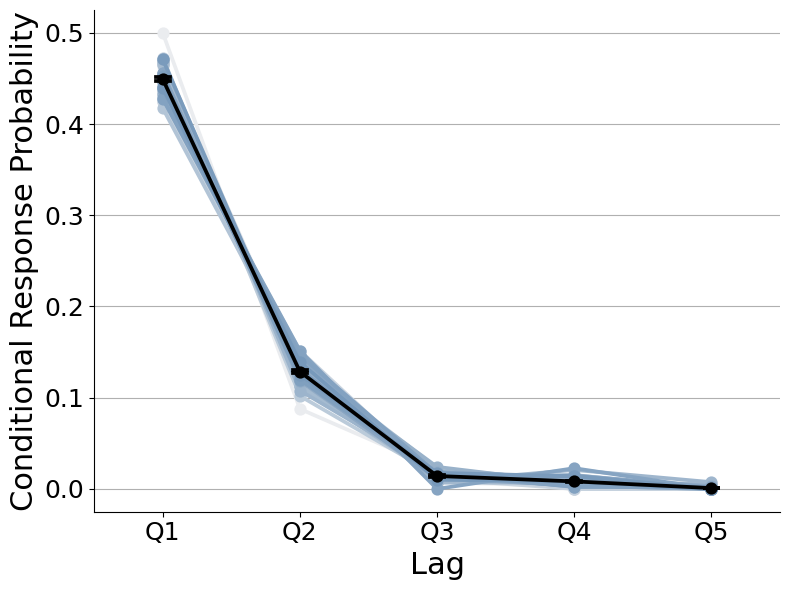

In [101]:
rows = []
for sub, crp in zip(subjects, spatial_CRPs):
    if crp is None or np.all(np.isnan(crp)): 
        continue
    for b, y in enumerate(crp, start=1):
        rows.append({"subject": sub, "bin": b, "bin_label": f"Q{b}", "crp": y})
df_long = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 6))

colors = sns.light_palette("#79B", df_long['subject'].nunique())
order = ["Q1","Q2","Q3","Q4","Q5"]
for i, sub in enumerate(subjects):
    sub_df = df_long[df_long["subject"] == sub]
    if sub_df.empty: 
        continue
    sns.pointplot(data=sub_df, x="bin_label", y="crp", 
                  order=order, color=colors[i], 
                  ax=ax, linestyles="-")

sns.pointplot(data=df_long, x="bin_label", y="crp", order=order, color="black", capsize=.1, ci=68, ax=ax)

ax.set_xlabel("Lag", fontsize=22)
ax.set_ylabel("Conditional Response Probability", fontsize=22)
ax.yaxis.grid()
ax.tick_params(labelsize=18)
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

plt.tight_layout()
plt.show()

In [102]:
# Simulated Recall 2: subsequent item is always from the farthest bin

rng = np.random.default_rng(1)
farthest_sim_trials = []

for day in sim_trials:
    items = day['items']
    serialpos = day['serialpos']
    bin_matrix = day['bin_matrix']
    n_items = len(items)
    if n_items == 0:
        continue

    start_idx = rng.integers(n_items)
    recalled = [start_idx]
    current_idx = start_idx
    
    while len(recalled) < min(10, n_items):
        unrecalled = [i for i in range(n_items) if i not in recalled]
        if len(unrecalled) == 0:
            break
        
        possible_bins = bin_matrix[current_idx, unrecalled]
        valid_mask = possible_bins > 0
        if not np.any(valid_mask):
            break
        valid_unrecalled = np.array(unrecalled)[valid_mask]
        valid_bins = possible_bins[valid_mask]

        farthest_bin = np.max(valid_bins)
        farthest_items = valid_unrecalled[valid_bins == farthest_bin]
        next_idx = rng.choice(farthest_items)
        recalled.append(next_idx)
        current_idx = next_idx

    farthest_sim_trials.append({
        'subject': day['subject'],
        'session': day['session'],
        'trial': day['trial'],
        'recalled_idx': np.array(recalled),
        'recalled_items': items[recalled],
        'recalled_serialpos': serialpos[recalled],
    })

In [106]:
farthest_rec_rows = []
for day in farthest_sim_trials:
    for recall_pos, (item, sp) in enumerate(zip(day['recalled_items'], day['recalled_serialpos']), start=1):
        farthest_rec_rows.append({
            'subject': day['subject'],
            'session': day['session'],
            'trial': day['trial'],
            'type': 'REC_WORD',
            'item': item,
            'serialpos': sp,
            'recallpos': recall_pos,
        })
farthest_rec_evs = pd.DataFrame(farthest_rec_rows)
farthest_rec_evs

,subject,session,trial,type,item,serialpos,recallpos
0,LTP564,1,0,REC_WORD,KEYBOARD,8,1
1,LTP564,1,0,REC_WORD,WEIGHTS,3,2
2,LTP564,1,0,REC_WORD,BANANA,10,3
3,LTP564,1,0,REC_WORD,VIOLIN,5,4
4,LTP564,1,0,REC_WORD,DOGFOOD,15,5
...,...,...,...,...,...,...,...
9185,LTP605,5,9,REC_WORD,CHICKEN,5,6
9186,LTP605,5,9,REC_WORD,SOFA,1,7
9187,LTP605,5,9,REC_WORD,POPCORN,13,8
9188,LTP605,5,9,REC_WORD,ASHTRAY,14,9


In [108]:
# Verify spatial CRP code using simulated data 2

spatial_CRPs = [[]]*len(subjects)
x_mids_by_sub = [[]]*len(subjects)
tot_act_by_sub = [[]]*len(subjects)
tot_pos_by_sub = [[]]*len(subjects)

for t, sub in enumerate(subjects):
    total_actual  = np.zeros(5, dtype=float)
    total_possible = np.zeros(5, dtype=float)
    mid_weighted_sum = np.zeros(5, dtype=float)
    
    sub_data = data[data.subject == sub]
    sub_CRP = []
    for sess in np.unique(sub_data.session):
        
        reader = cml.CMLReader(subject=sub, session=sess, experiment='CourierReinstate1')
        evs = reader.load('task_events')
        rec_evs = farthest_rec_evs[(farthest_rec_evs['subject'] == sub) & (farthest_rec_evs['session'] == sess)].sort_values(['trial', 'recallpos'])
        word_evs = evs[evs.type == 'WORD']
        if len(word_evs) > 150:
            continue
        pres_words = np.array(word_evs.item)
        
        pres_loc = []
        for i in range(len(word_evs)):
            pres_loc.append([np.array(word_evs.presX)[i], np.array(word_evs.presZ)[i]])
        pres_loc = np.array(pres_loc)

        item_dists = []
        for i in range(min(len(pres_loc), 150)):
            temp_dists = []
            for j in range(min(len(pres_loc), 150)):
                temp_dists.append(compute_distance(pres_loc[i], pres_loc[j]))
            item_dists.append(temp_dists)
        item_dists = np.array(item_dists)

        flat = item_dists[np.triu_indices_from(item_dists, k=1)]
        if flat.size == 0:
            continue
        edges = np.quantile(flat, [0, .2, .4, .6, .8, 1.0])
        for i in range(1, len(edges)):
            if edges[i] <= edges[i-1]:
                edges[i] = np.nextafter(edges[i-1], np.inf)
        cutpoints = edges[1:-1] 
        mids = (edges[:-1] + edges[1:]) / 2
        
        actual_transitions = []
        possible_transitions = []
        for list in np.unique(rec_evs.trial):
            list_recs = rec_evs[rec_evs.trial == list]
            list_enc = word_evs[word_evs.trial == list]
            list_pres_words = np.array(list_enc.item)
            serpos = np.array(range(0,15))
            list_dist = []
            if len(list_enc) < 15:
                continue
                
            for recs in range(1, len(list_recs)):
                rec_word = np.array(list_recs.item)[recs - 1]
                next_rec = np.array(list_recs.item)[recs]
                if np.in1d(rec_word, np.array(list_enc.item)) == False:  # skip intrusions
                    continue
                if np.in1d(next_rec, np.array(list_enc.item)) == False:
                    continue
                if np.in1d(rec_word, np.array(list_recs.item)[:recs-1]):  # skip repeats
                    continue
                if np.in1d(next_rec, np.array(list_recs.item)[:recs-1]):
                    continue       

                # Get spatial distance bins between current recall and all other words
                temp_dists = []
                for i in range(len(list_enc.item)):
                    curr_word = np.array(list_enc.item)[i]
                    dist = item_dists[np.where(pres_words == rec_word)[0][0]][np.where(pres_words == curr_word)[0][0]]
                    temp_dists.append(dist)
                    
                temp_dists = np.array(temp_dists)
                temp_inds = np.digitize(temp_dists, cutpoints) + 1
                
                actual_transitions = np.append(actual_transitions, temp_inds[np.array(list_recs.serialpos)[recs] - 1]) # Distance bin of actual transition
                not_yet_rec = np.in1d(serpos, np.array(list_recs.serialpos)[:recs] - 1) == False
                possible_transitions = np.append(possible_transitions, temp_inds[(not_yet_rec == True) & (np.array(temp_dists) > 0)])
                
        sess_actual   = np.array([np.sum(actual_transitions   == b) for b in range(1, 6)], dtype=float)
        sess_possible = np.array([np.sum(possible_transitions == b) for b in range(1, 6)], dtype=float)
        total_actual  += sess_actual
        total_possible += sess_possible
        mid_weighted_sum += mids * sess_possible


        actual_sum = []
        possible_sum = []
        for i in range(1,6):
            actual_sum.append(sum(actual_transitions == i))
            possible_sum.append(sum(possible_transitions == i))

        CRP = np.array(actual_sum)/np.array(possible_sum)
        sub_CRP.append(CRP)
        
        for b in range(1, 6):
            total_actual[b-1]  += np.sum(actual_transitions == b)
            total_possible[b-1] += np.sum(possible_transitions == b)

    spatial_CRPs[t] = np.divide(total_actual, total_possible, out=np.full(5, np.nan), where=total_possible > 0)
    x_mids_by_sub[t] = np.divide(mid_weighted_sum, total_possible, out=np.full(5, np.nan), where=total_possible > 0)
    tot_act_by_sub[t] = total_actual
    tot_pos_by_sub[t] = total_possible

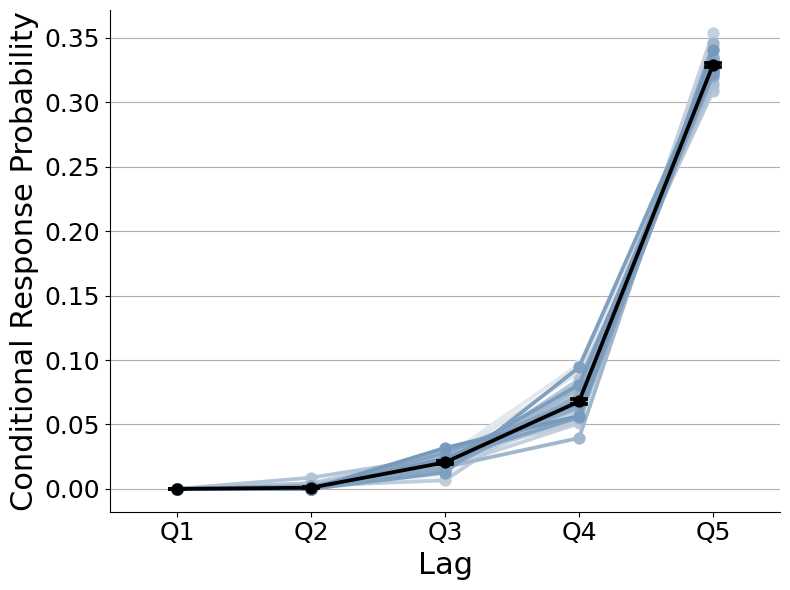

In [109]:
rows = []
for sub, crp in zip(subjects, spatial_CRPs):
    if crp is None or np.all(np.isnan(crp)): 
        continue
    for b, y in enumerate(crp, start=1):
        rows.append({"subject": sub, "bin": b, "bin_label": f"Q{b}", "crp": y})
df_long = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 6))

colors = sns.light_palette("#79B", df_long['subject'].nunique())
order = ["Q1","Q2","Q3","Q4","Q5"]
for i, sub in enumerate(subjects):
    sub_df = df_long[df_long["subject"] == sub]
    if sub_df.empty: 
        continue
    sns.pointplot(data=sub_df, x="bin_label", y="crp", 
                  order=order, color=colors[i], 
                  ax=ax, linestyles="-")

sns.pointplot(data=df_long, x="bin_label", y="crp", order=order, color="black", capsize=.1, ci=68, ax=ax)

ax.set_xlabel("Lag", fontsize=22)
ax.set_ylabel("Conditional Response Probability", fontsize=22)
ax.yaxis.grid()
ax.tick_params(labelsize=18)
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

plt.tight_layout()
plt.show()